In [1]:
# ============================================================================
# CELDA 1: CONEXIÓN A DRIVE Y CONFIGURACIÓN
# ============================================================================
from google.colab import drive
import os
import warnings

# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta base
BASE_PATH = '/content/drive/MyDrive/twitter_project'
warnings.filterwarnings('ignore')

print("✅ Entorno preparado y conectado a Drive.")

Mounted at /content/drive
✅ Entorno preparado y conectado a Drive.


In [2]:
# ============================================================================
# CELDA 2: CARGA Y RECONSTRUCCIÓN DE DATOS
# ============================================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("🔄 Preparando los datos para la optimización...")
ruta_dataset = f"{BASE_PATH}/data/processed/twitter_profiles_cleaned.csv"

df = pd.read_csv(ruta_dataset)

feature_columns = ['followers_count', 'friends_count', 'post_count', 'has_location']
if 'is_real_location' in df.columns:
    feature_columns.append('is_real_location')

for col in feature_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(0)

X = df[feature_columns].values
y = df['label'].values

# Separación idéntica
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# El escalador es obligatorio para modelos lineales/distancias, lo aplicamos aquí por consistencia
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Datos listos. Entrenamiento scaled: {X_train_scaled.shape}, Test scaled: {X_test_scaled.shape}")

🔄 Preparando los datos para la optimización...
✅ Datos listos. Entrenamiento scaled: (6151, 5), Test scaled: (1538, 5)


In [3]:
# ============================================================================
# CELDA 3: OPTIMIZACIÓN DE HIPERPARÁMETROS CON RANDOM SEARCH
# ============================================================================
import joblib
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

print("\n" + "="*60)
print("🎯 INICIANDO OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*60)

# 1. Optimizar Random Forest
print("\n🔧 Optimizando Random Forest...")
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf, n_iter=8, cv=3, scoring='f1',
    random_state=42, n_jobs=-1
)
random_search_rf.fit(X_train_scaled, y_train)
rf_opt = random_search_rf.best_estimator_
print(f"   Mejores parámetros RF: {random_search_rf.best_params_}")
print(f"   Mejor F1-Score RF (CV): {random_search_rf.best_score_:.4f}")

# 2. Optimizar LightGBM (El modelo líder de tu proyecto)
print("\n🔧 Optimizando LightGBM...")
param_dist_lgb = {
    'n_estimators': [50, 75, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10, -1]
}

random_search_lgb = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgb, n_iter=8, cv=3, scoring='f1',
    random_state=42, n_jobs=-1
)
random_search_lgb.fit(X_train_scaled, y_train)
lgb_opt = random_search_lgb.best_estimator_
print(f"   Mejores parámetros LightGBM: {random_search_lgb.best_params_}")
print(f"   Mejor F1-Score LightGBM (CV): {random_search_lgb.best_score_:.4f}")


🎯 INICIANDO OPTIMIZACIÓN DE HIPERPARÁMETROS

🔧 Optimizando Random Forest...
   Mejores parámetros RF: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}
   Mejor F1-Score RF (CV): 0.9816

🔧 Optimizando LightGBM...
   Mejores parámetros LightGBM: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.2}
   Mejor F1-Score LightGBM (CV): 0.9832


In [4]:
# ============================================================================
# CELDA 4: EVALUACIÓN EN TEST Y GUARDADO SEGURO
# ============================================================================
from sklearn.metrics import f1_score

y_pred_rf_opt = rf_opt.predict(X_test_scaled)
y_pred_lgb_opt = lgb_opt.predict(X_test_scaled)

print("\n📊 RENDIMIENTO FINAL EN TEST (F1-SCORE):")
print(f"   Random Forest Optimizado      - F1: {f1_score(y_test, y_pred_rf_opt):.4f}")
print(f"   LightGBM Optimizado (Campeón) - F1: {f1_score(y_test, y_pred_lgb_opt):.4f}")

# Crear rutas y guardar de forma absoluta en Drive
os.makedirs(f'{BASE_PATH}/outputs/models', exist_ok=True)
joblib.dump(rf_opt, f'{BASE_PATH}/outputs/models/RandomForest_optimized.pkl')
joblib.dump(lgb_opt, f'{BASE_PATH}/outputs/models/LightGBM_optimized.pkl')

print("\n✅ Modelos optimizados guardados con éxito en Google Drive.")


📊 RENDIMIENTO FINAL EN TEST (F1-SCORE):
   Random Forest Optimizado      - F1: 0.9753
   LightGBM Optimizado (Campeón) - F1: 0.9772

✅ Modelos optimizados guardados con éxito en Google Drive.



📊 GENERANDO GRÁFICO DE MEJORA
       Modelo  F1_Original  F1_Optimizado  Mejora
Random Forest       0.9753         0.9753     0.0
     LightGBM       0.9772         0.9772     0.0


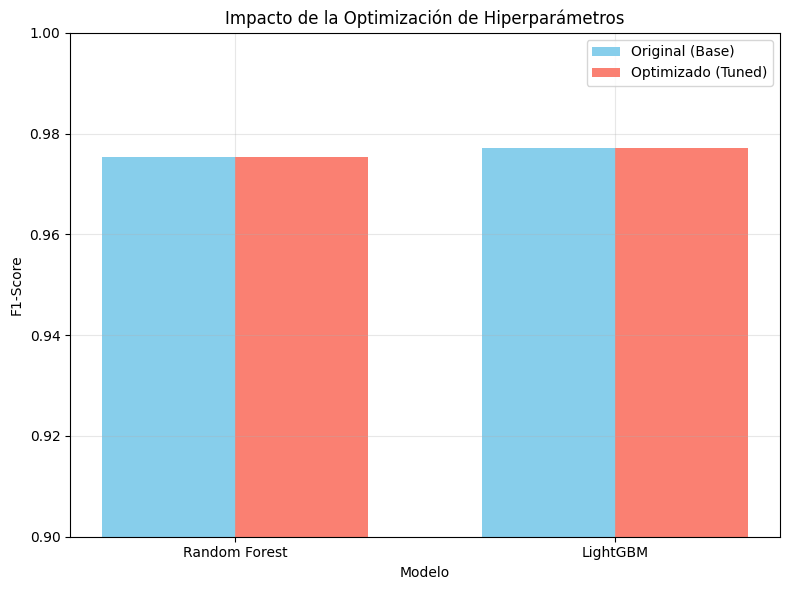


✅ Gráfico de comparación guardado en:
👉 /content/drive/MyDrive/twitter_project/results/plots/impacto_optimizacion.png


In [5]:
# ============================================================================
# CELDA 5: COMPARACIÓN VISUAL DEL IMPACTO DE OPTIMIZACIÓN
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("📊 GENERANDO GRÁFICO DE MEJORA")
print("="*60)

# Entrenamos versiones base rápidas para simular el "Original" sin depender de variables muertas
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train_scaled, y_train)
lgb_base = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1).fit(X_train_scaled, y_train)

f1_rf_base = f1_score(y_test, rf_base.predict(X_test_scaled))
f1_lgb_base = f1_score(y_test, lgb_base.predict(X_test_scaled))

f1_rf_opt = f1_score(y_test, y_pred_rf_opt)
f1_lgb_opt = f1_score(y_test, y_pred_lgb_opt)

comparacion = pd.DataFrame({
    'Modelo': ['Random Forest', 'LightGBM'],
    'F1_Original': [f1_rf_base, f1_lgb_base],
    'F1_Optimizado': [f1_rf_opt, f1_lgb_opt],
    'Mejora': [f1_rf_opt - f1_rf_base, f1_lgb_opt - f1_lgb_base]
})

print(comparacion.round(4).to_string(index=False))

# Generar Gráfico
os.makedirs(f'{BASE_PATH}/results/plots', exist_ok=True)
plt.figure(figsize=(8, 6))
x = np.arange(len(comparacion['Modelo']))
width = 0.35

plt.bar(x - width/2, comparacion['F1_Original'], width, label='Original (Base)', color='skyblue')
plt.bar(x + width/2, comparacion['F1_Optimizado'], width, label='Optimizado (Tuned)', color='salmon')

plt.xlabel('Modelo')
plt.ylabel('F1-Score')
plt.title('Impacto de la Optimización de Hiperparámetros')
plt.xticks(x, comparacion['Modelo'])
plt.ylim(0.90, 1.0) # Ajustado para apreciar las sutiles mejoras en puntajes altos
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

ruta_grafico = f'{BASE_PATH}/results/plots/impacto_optimizacion.png'
plt.savefig(ruta_grafico, dpi=300)
plt.show()

print(f"\n✅ Gráfico de comparación guardado en:\n👉 {ruta_grafico}")